## Resources

- [Squidpy MERFISH Tutorial](https://squidpy.readthedocs.io/en/stable/notebooks/tutorials/tutorial_merfish.html)

### Cell 1: Environment Setup for Google Colab

In [3]:
# Install required packages for spatial analysis on Google Colab
!pip install -q numpy pandas anndata scanpy squidpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.9/61.9 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.2/199.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/

### Cell 2: Import Packages and Load Data

In [4]:
import scanpy as sc
import squidpy as sq
import matplotlib.pyplot as plt

sc.logging.print_header()
print(f"squidpy=={sq.__version__}")

# Load the pre-processed MERFISH dataset
adata = sq.datasets.merfish()
display(adata)

squidpy==1.8.1
INFO     Downloading merfish.h5ad from https://exampledata.scverse.org/squidpy/figshare/merfish.h5ad               


  0%|                                              | 0.00/51.6M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 73655 × 161
    obs: 'Cell_ID', 'Animal_ID', 'Animal_sex', 'Behavior', 'Bregma', 'Centroid_X', 'Centroid_Y', 'Cell_class', 'Neuron_cluster_ID', 'batch'
    uns: 'Cell_class_colors'
    obsm: 'spatial', 'spatial3d'

### Cell 3: 3D Visualization of Cell Classes

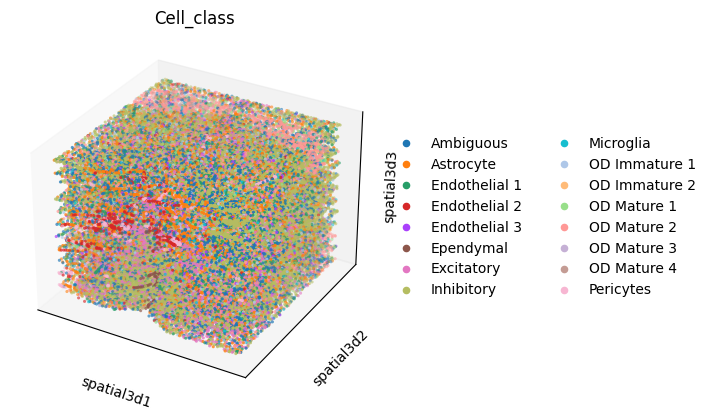

In [5]:
# Visualize the 3D stack of slides
sc.pl.embedding(
    adata,
    basis="spatial3d",
    projection="3d",
    color="Cell_class",
    show=False
)

# Save and show the plot
plt.savefig("merfish_3d_cell_class.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 4: 2D Visualization of a Single Slice

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_color_utils.py:28: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  target.uns[color_key] = source.uns[color_key]
/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


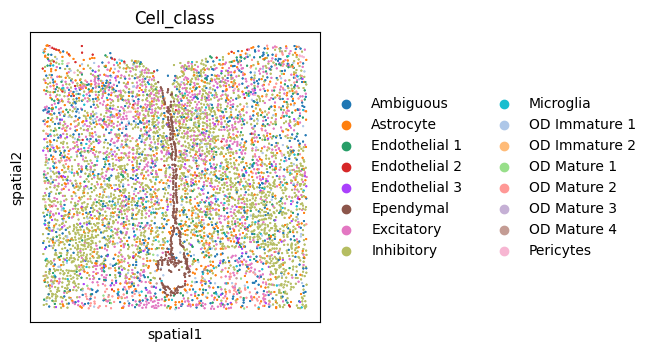

In [6]:
# Visualize a single slide (Bregma = -9)
# Note: show=False is omitted here to prevent matplotlib PatchCollection errors
sq.pl.spatial_scatter(
    adata[adata.obs.Bregma == -9],
    shape=None,
    color="Cell_class",
    size=1
)

# Save and show the plot
plt.savefig("merfish_2d_slice_bregma_minus9.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 5: Neighborhood Enrichment Analysis in 3D

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/1000 [00:00<?, ?/s]

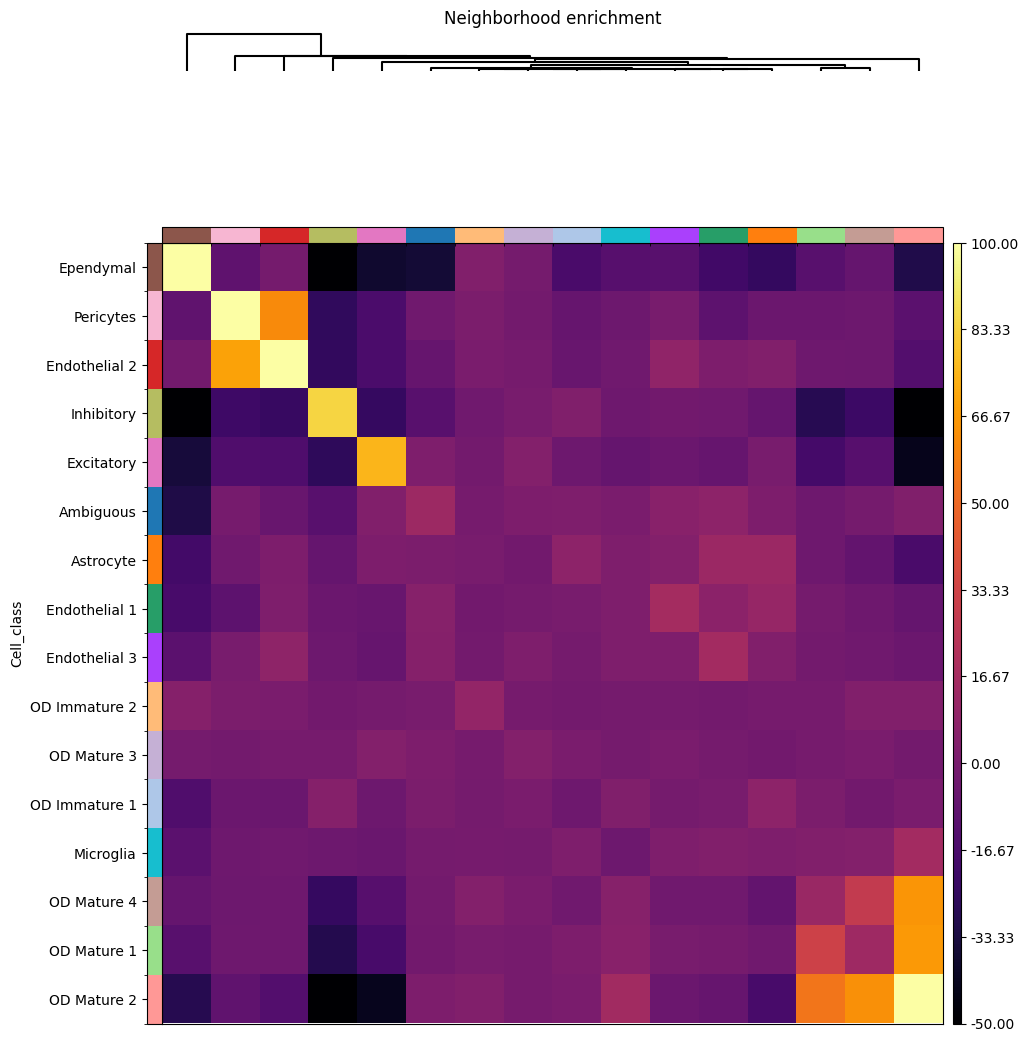

In [7]:
# Compute neighbor graph on the 3D coordinate space
sq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial3d")

# Compute neighborhood enrichment score
sq.gr.nhood_enrichment(adata, cluster_key="Cell_class")

# Visualize the enrichment score
sq.pl.nhood_enrichment(
    adata,
    cluster_key="Cell_class",
    method="single",
    cmap="inferno",
    vmin=-50,
    vmax=100,
    show=False
)

# Save and show the plot
plt.savefig("merfish_3d_nhood_enrichment.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 6: Visualize Co-enriched Clusters in 3D

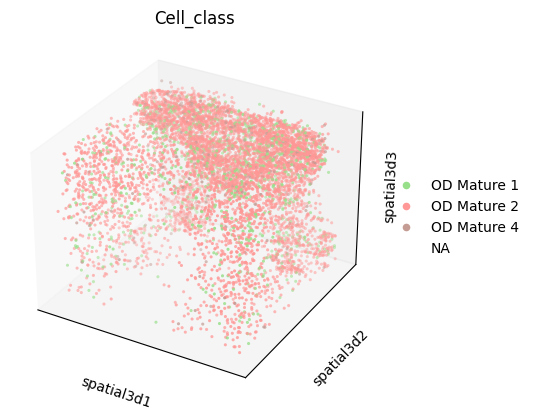

In [8]:
# Visualize some of the co-enriched clusters making other observations transparent
sc.pl.embedding(
    adata,
    basis="spatial3d",
    groups=["OD Mature 1", "OD Mature 2", "OD Mature 4"],
    na_color=(1, 1, 1, 0),
    projection="3d",
    color="Cell_class",
    show=False
)

# Save and show the plot
plt.savefig("merfish_3d_coenriched_clusters.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 7: Differential Expression and 3D Gene Expression

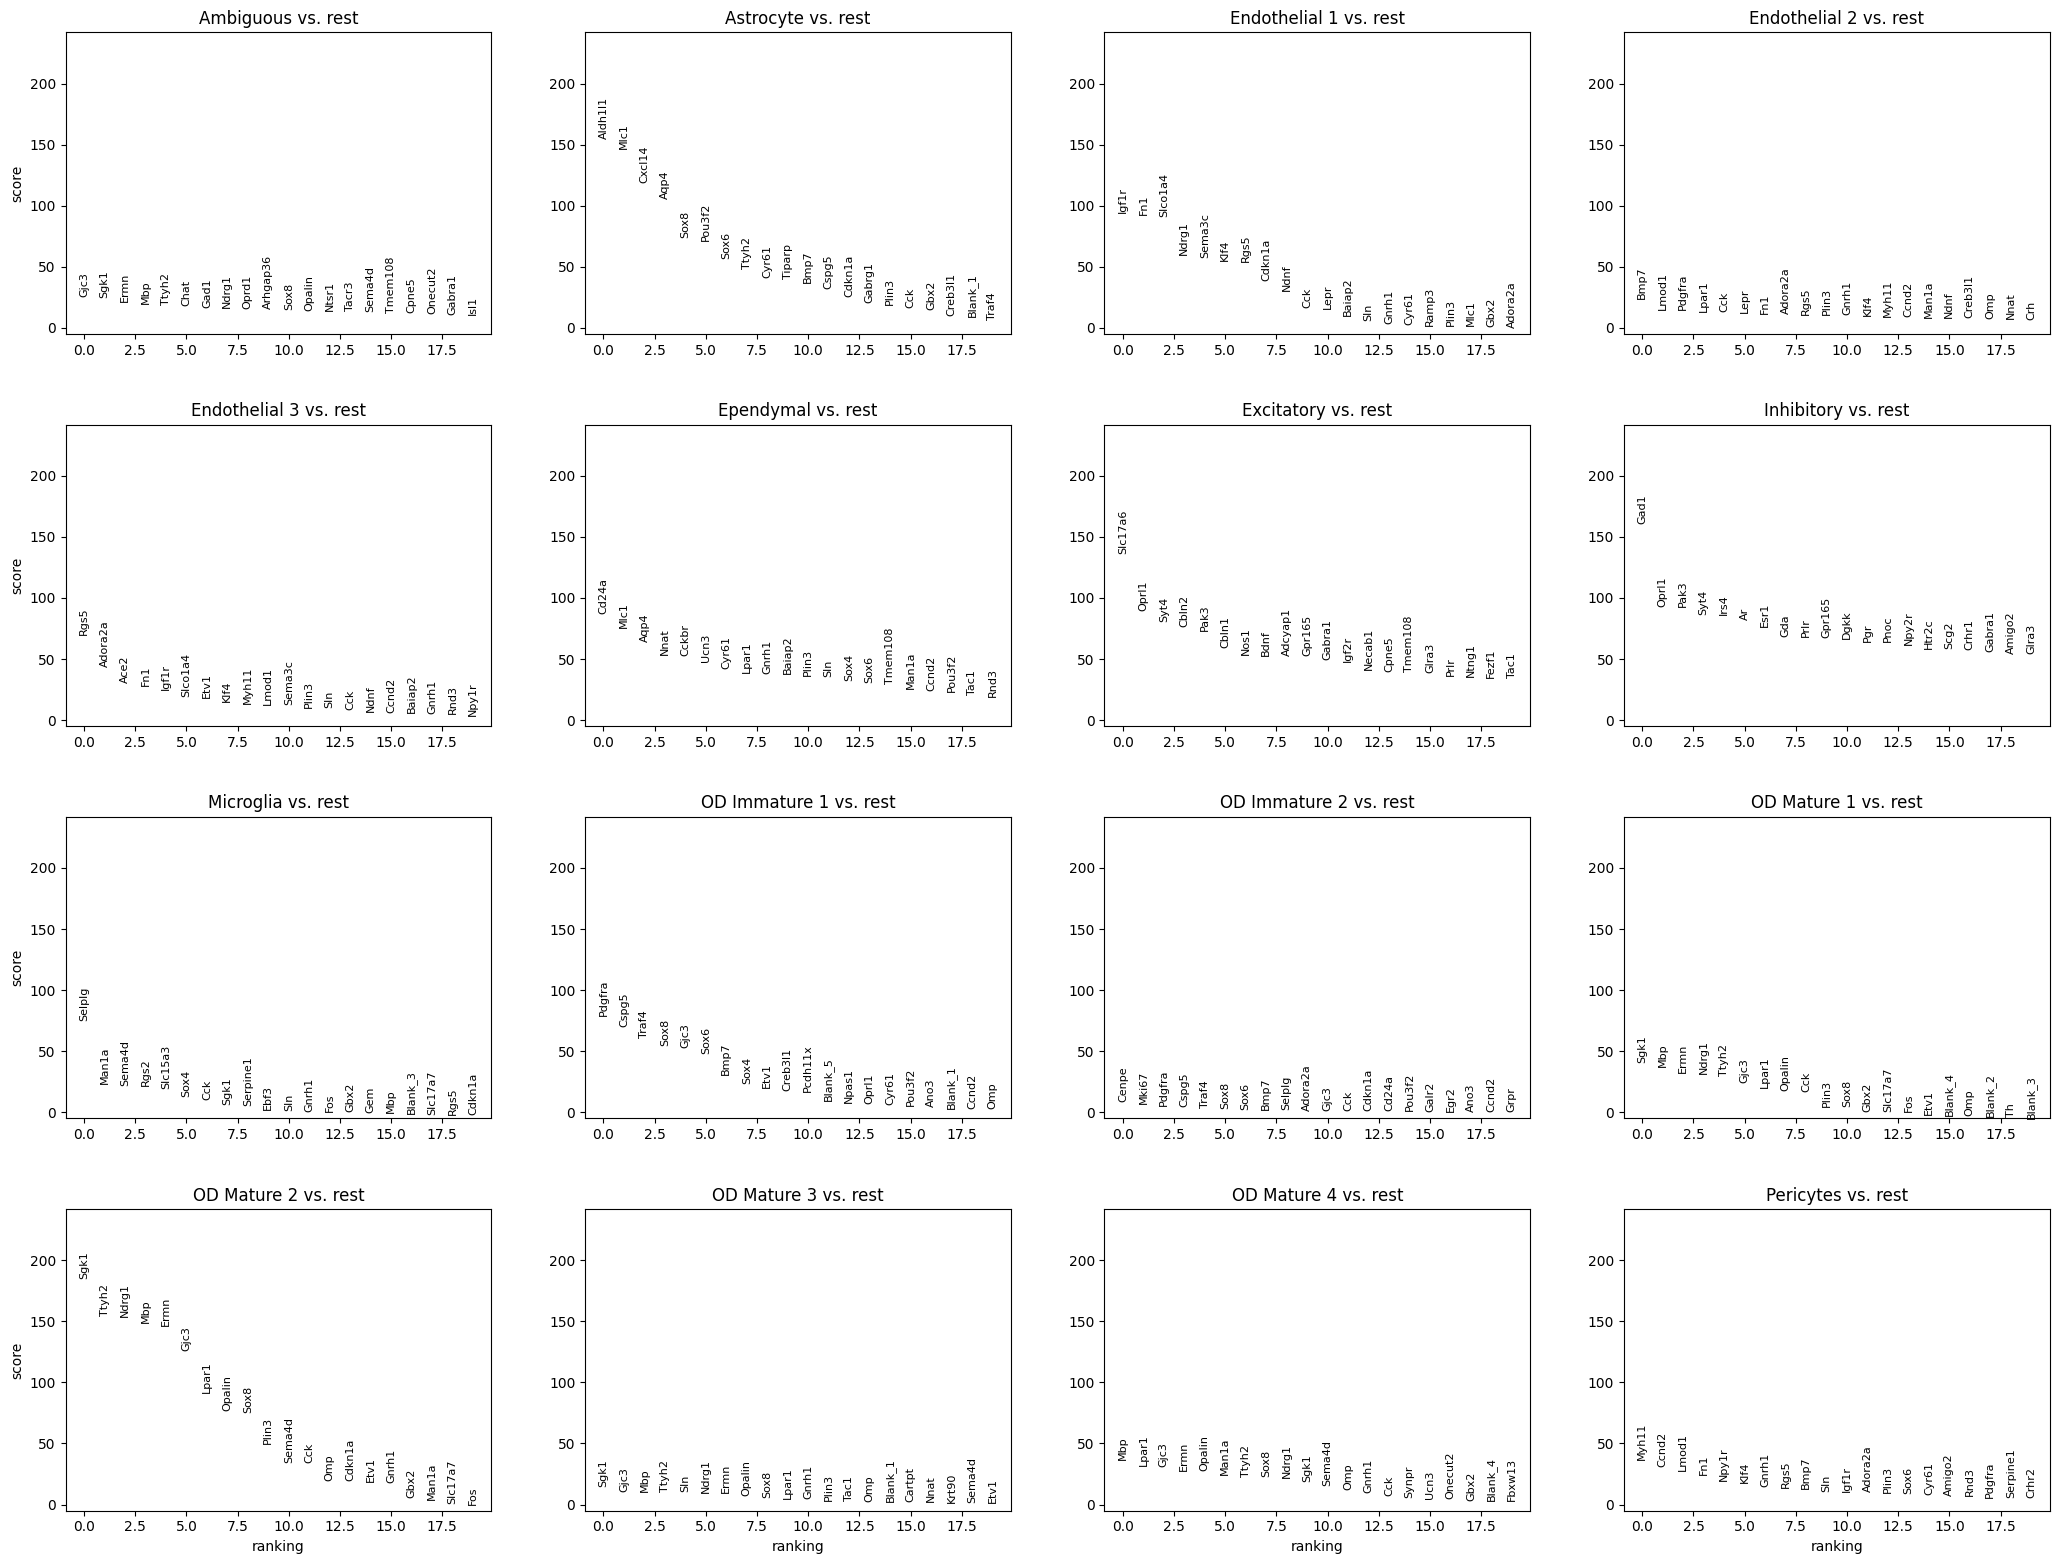

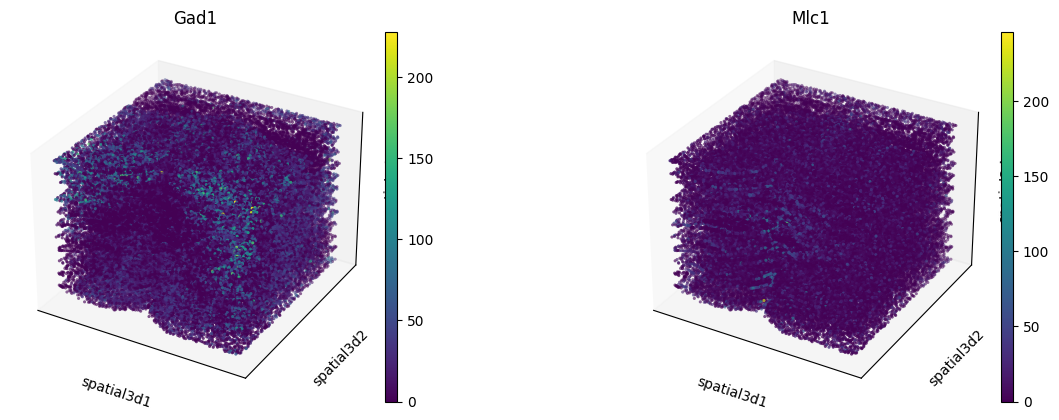

In [9]:
# Perform differential expression testing
sc.tl.rank_genes_groups(adata, groupby="Cell_class", method="t-test")

# Visualize rank genes groups
sc.pl.rank_genes_groups(adata, groupby="Cell_class", show=False)
plt.savefig("merfish_rank_genes_groups.png", bbox_inches="tight", dpi=300)
plt.show()

# Visualize expression of specific genes in 3D coordinates
sc.pl.embedding(
    adata,
    basis="spatial3d",
    projection="3d",
    color=["Gad1", "Mlc1"],
    show=False
)
plt.savefig("merfish_3d_gene_expression.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 8: 2D Spatial Analysis on a Single Slice

INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        


  0%|          | 0/1000 [00:00<?, ?/s]

/usr/local/lib/python3.12/dist-packages/squidpy/pl/_spatial_utils.py:982: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


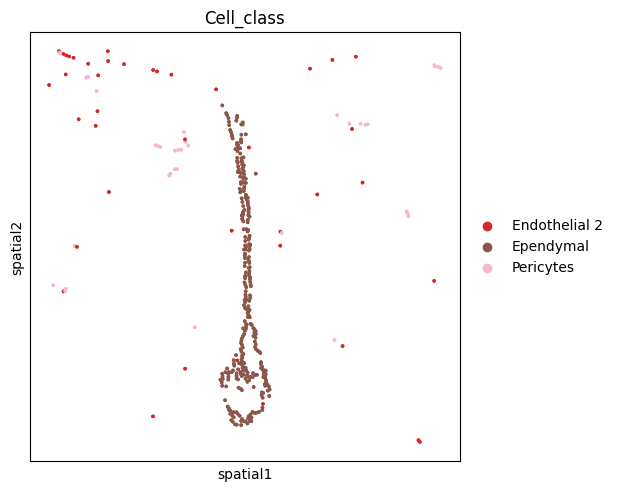

In [10]:
# Copy the sample of interest into a new AnnData object for 2D analysis
adata_slice = adata[adata.obs.Bregma == -9].copy()

# Compute spatial neighbors and neighborhood enrichment on the 2D slice
sq.gr.spatial_neighbors(adata_slice, coord_type="generic")
sq.gr.nhood_enrichment(adata_slice, cluster_key="Cell_class") # Note: Fixed from tutorial to use adata_slice

# Visualize specific groups on the single slice
sq.pl.spatial_scatter(
    adata_slice,
    color="Cell_class",
    shape=None,
    groups=[
        "Ependymal",
        "Pericytes",
        "Endothelial 2",
    ],
    size=10
)

# Save and show the plot
plt.savefig("merfish_2d_slice_nhood_scatter.png", bbox_inches="tight", dpi=300)
plt.show()

### Cell 9: Spatially Variable Genes (Moran's I)

/usr/lib/python3.12/functools.py:912: UserWarning: 1 variables were constant, will return nan for these.
  return dispatch(args[0].__class__)(*args, **kw)


,I,pval_norm,var_norm,pval_norm_fdr_bh
Nnat,0.733661,0.0,0.00005,NaN
Sln,0.639211,0.0,0.00005,NaN
Cd24a,0.606546,0.0,0.00005,NaN
Necab1,0.399385,0.0,0.00005,NaN
Mbp,0.397534,0.0,0.00005,NaN


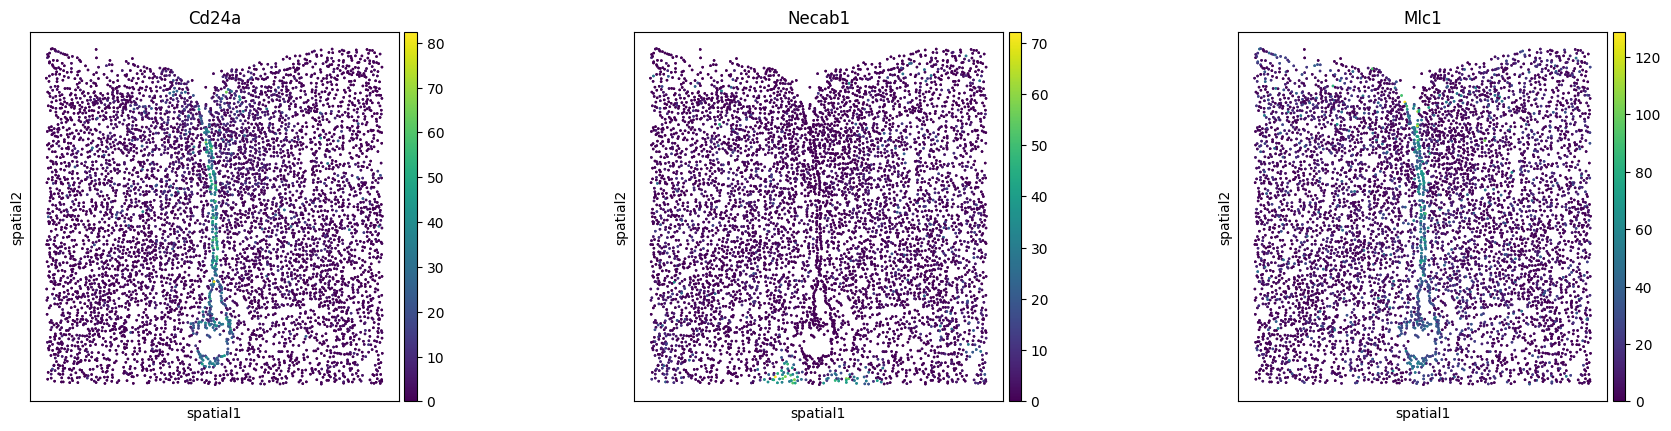

In [11]:
# Investigate spatial variability of gene expression using Moran's I
sq.gr.spatial_autocorr(adata_slice, mode="moran")

# Display the top spatially variable genes
display(adata_slice.uns["moranI"].head())

# Visualize selected highly spatially variable genes
sq.pl.spatial_scatter(
    adata_slice,
    shape=None,
    color=["Cd24a", "Necab1", "Mlc1"],
    size=3
)

# Save and show the plot
plt.savefig("merfish_2d_slice_morans_I_genes.png", bbox_inches="tight", dpi=300)
plt.show()